# Analyze district income and STAAR results

This notebook merges district-level income estimates with district-level Spring 2026 STAAR results.

The main question is simple:

> How closely does median household income in a district predict STAAR passing rates?

The notebook does three things:

1. Builds a statewide income + STAAR analysis file.
2. Fits a simple statewide regression of STAAR Approaches rate on median household income.
3. Uses regression residuals to identify districts that perform above or below what the statewide income relationship would predict.

A few important caveats:

- Correlation does not imply causation. There are many factors that predict STAAR scores, including class size, SPED and ESL population, etc
- Still, I feel pretty good about our p value and R^2
- Median household income is measured for school district geography, not for tested students' households.
- STAAR results are based on test administrations, not unique students.
- The STAAR outcome is the districtwide share of included test administrations at **Approaches Grade Level or Above**.
- District name matching is mostly exact. Duplicate district names are handled with a manual crosswalk
- The actual regression focuses on districts with > 500 tests administered
- I mainly feel ok omitting very small districts

- Two major exceptions: Texas School for the Blind and Texas School for the Deaf
- These public schools are not included in this analysis. We do not have median income (since they are not a traditional school district)
- They also have VERY small testing populations
- Still, their passing rates are abysmal. This possibly warrants a follow-up article



In [6]:
%pip install adjustText

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import linregress

In [8]:
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
})

# consistent formatting

## File paths

This notebook assumes it is run from the `notebooks/` folder.

It uses the processed files created by Notebook 1 and Notebook 2, plus a small manual crosswalk for duplicate district names.

Expected files:

```text
data/processed/district_income.csv
data/processed/district_staar_summary.csv
data/raw/duplicate_district_crosswalk.csv (manually compiled from https://tealprod.tea.state.tx.us/TEA.AskTED.TSD/TSDfiles/tsd2000/psdlasbo.pdf)
```


In [9]:
RAW_DATA = Path("../data/raw")
PROCESSED_DATA = Path("../data/processed")

INCOME_FILE = PROCESSED_DATA / "district_income.csv"
STAAR_FILE = PROCESSED_DATA / "district_staar_summary.csv"
CROSSWALK_FILE = RAW_DATA / "duplicate_district_crosswalk.csv"

OUTPUT_FILE = PROCESSED_DATA / "district_income_staar_analysis.csv" 

## Load processed files

In [10]:
district_income = pd.read_csv(INCOME_FILE)
district_staar = pd.read_csv(STAAR_FILE)

# Read the crosswalk district ID as a string so leading zeros stay intact.
duplicate_crosswalk = pd.read_csv(
    CROSSWALK_FILE,
    dtype={"tea_district_id": str},
) #manually made this file from this pdf:
 # in retrosepct, I should have just scraped this pdf from the beginning
 # but at this point in the project, I did not want to scrape it just to fix 20-ish districts

 # source: https://tealprod.tea.state.tx.us/TEA.AskTED.TSD/TSDfiles/tsd2000/psdlasbo.pdf

district_income.shape, district_staar.shape, duplicate_crosswalk.shape

((1018, 7), (1018, 6), (22, 3))

In [11]:
district_income.head()

,gisjoin,year,state,district,district_code,median_household_income,income_moe
0,G48007380,2020-2024,Texas,Abbott ISD,7380,88750.0,26095.0
1,G48007410,2020-2024,Texas,Abernathy ISD,7410,83073.0,12492.0
2,G48007440,2020-2024,Texas,Abilene ISD,7440,58822.0,1489.0
3,G48007470,2020-2024,Texas,Academy ISD,7470,95390.0,4391.0
4,G48007500,2020-2024,Texas,Adrian ISD,7500,73125.0,24647.0


In [12]:
district_staar.head()

,district,tea_district_id,administration,tests_taken,approaches_count,approaches_pct
0,ABBOTT ISD,109901,Spring 2026,351.0,318.0,90.598291
1,ABERNATHY ISD,95901,Spring 2026,1109.0,916.0,82.596934
2,ABILENE ISD,221901,Spring 2026,18226.0,12139.0,66.602656
3,ACADEMY ISD,14901,Spring 2026,2581.0,2099.0,81.325068
4,ADRIAN ISD,180903,Spring 2026,188.0,135.0,71.808511


In [13]:
duplicate_crosswalk

,income_district,tea_district_id,note
0,Big Sandy ISD (Polk County),187901,Resolved using TEA district list: Big Sandy IS...
1,Big Sandy ISD (Upshur and Wood Counties),230901,Resolved using TEA district list: Big Sandy IS...
2,Centerville ISD (Leon County),145902,Resolved using TEA district list: Centerville ...
3,Centerville ISD (Trinity County),228904,Resolved using TEA district list: Centerville ...
4,Chapel Hill ISD (Smith County),212909,Resolved using TEA district list: Chapel Hill ...
5,Chapel Hill ISD (Titus County),225906,Resolved using TEA district list: Chapel Hill ...
6,"Dawson ISD (Dawson, Lynn, and Terry Counties)",058902,Resolved using TEA district list: Dawson 058 902
7,Dawson ISD (Hill and Navarro Counties),175904,Resolved using TEA district list: Dawson ISD 1...
8,Edgewood ISD (Bexar County),015905,Resolved using TEA district list: Edgewood ISD...
9,Edgewood ISD (Van Zandt County),234903,Resolved using TEA district list: Edgewood ISD...


## Standardize TEA district IDs and district names

TEA district IDs are six-character identifiers. Some files may read them as numbers and drop leading zeros.

This cell stores them as six-character strings so merges work consistently.

We did this already in notebook two, but those 0's can be lost at any time if you accidentally open the file and hit "ok"

In [14]:
district_income = district_income.copy()
district_staar = district_staar.copy()
duplicate_crosswalk = duplicate_crosswalk.copy()

district_staar["tea_district_id"] = (
    pd.to_numeric(
        district_staar["tea_district_id"],
        errors="raise",
    )
    .astype(int)
    .astype(str)
    .str.zfill(6)
)

duplicate_crosswalk["tea_district_id"] = (
    duplicate_crosswalk["tea_district_id"]
    .astype(str)
    .str.zfill(6)
)

district_income["district_match_name"] = (
    district_income["district"]
    .astype(str)
    .str.upper()
    .str.strip()
)

district_staar["district_match_name"] = (
    district_staar["district"]
    .astype(str)
    .str.upper()
    .str.strip()
)

duplicate_crosswalk["income_district_match_name"] = (
    duplicate_crosswalk["income_district"]
    .astype(str)
    .str.upper()
    .str.strip()
)

district_staar[["district", "tea_district_id", "district_match_name"]].head()

,district,tea_district_id,district_match_name
0,ABBOTT ISD,109901,ABBOTT ISD
1,ABERNATHY ISD,095901,ABERNATHY ISD
2,ABILENE ISD,221901,ABILENE ISD
3,ACADEMY ISD,014901,ACADEMY ISD
4,ADRIAN ISD,180903,ADRIAN ISD


## Clean simple name differences

These are one-to-one naming differences between the income file and the STAAR file.

I discovered these when an earlier merged dropped them. Manual inspection showed these are the exact same districts

In [15]:
name_cleanup_crosswalk = {
    "EAGLE MOUNTAIN-SAGINAW ISD": "EAGLE MT-SAGINAW ISD",
    "FORT DAVIS ISD": "FT DAVIS ISD",
    "FORT HANCOCK ISD": "FT HANCOCK ISD",
    "FORT SAM HOUSTON ISD": "FT SAM HOUSTON ISD",
    "GOLD-BURG ISD": "GOLD BURG ISD",
    "GOLDTHWAITE CISD": "GOLDTHWAITE ISD",
    "HAMLIN ISD": "HAMLIN COLLEGIATE ISD",
    "KENEDY COUNTY-WIDE CSD": "KENEDY COUNTY WIDE CSD",
    "LAPOYNER ISD": "LAPOYNOR ISD",
    "SCHERTZ-CIBOLO-UNIVERSAL CITY ISD": "SCHERTZ-CIBOLO-U CITY ISD",
    "WEST RUSK COUNTY CISD": "WEST RUSK COUNTY CONSOLIDATED ISD",
}

# Apply these before the exact merge so the cleaned names merge naturally.
district_income["district_match_name"] = (
    district_income["district_match_name"]
    .replace(name_cleanup_crosswalk)
)


## Check duplicate STAAR district names

Some Texas districts share the same name but have different TEA district IDs.

Those districts should not be merged by name alone.


In [16]:
duplicate_staar_names = (
    district_staar["district_match_name"]
    .value_counts()
    .loc[lambda s: s > 1]
    .index
)

duplicate_staar = (
    district_staar[
        district_staar["district_match_name"].isin(duplicate_staar_names)
    ]
    .sort_values(["district_match_name", "tea_district_id"])
)

duplicate_staar
#matches what we saw earlier

,district,tea_district_id,administration,tests_taken,approaches_count,approaches_pct,district_match_name
67,BIG SANDY ISD,187901,Spring 2026,695.0,600.0,86.330935,BIG SANDY ISD
68,BIG SANDY ISD,230901,Spring 2026,874.0,610.0,69.794050,BIG SANDY ISD
152,CENTERVILLE ISD,145902,Spring 2026,863.0,637.0,73.812283,CENTERVILLE ISD
153,CENTERVILLE ISD,228904,Spring 2026,195.0,143.0,73.333333,CENTERVILLE ISD
158,CHAPEL HILL ISD,212909,Spring 2026,4231.0,2746.0,64.901914,CHAPEL HILL ISD
159,CHAPEL HILL ISD,225906,Spring 2026,1258.0,1019.0,81.001590,CHAPEL HILL ISD
237,DAWSON ISD,058902,Spring 2026,188.0,129.0,68.617021,DAWSON ISD
236,DAWSON ISD,175904,Spring 2026,806.0,542.0,67.245658,DAWSON ISD
281,EDGEWOOD ISD,015905,Spring 2026,8882.0,4908.0,55.257825,EDGEWOOD ISD
282,EDGEWOOD ISD,234903,Spring 2026,1396.0,1090.0,78.080229,EDGEWOOD ISD


## Exact name merge

First, merge districts whose names match exactly and whose STAAR name is not duplicated.

This avoids accidentally matching one income row to multiple STAAR districts with the same name.


In [17]:
single_staar_names = (
    district_staar["district_match_name"]
    .value_counts()
    .loc[lambda s: s == 1]
    .index
)

income_for_exact_merge = district_income[
    district_income["district_match_name"].isin(single_staar_names)
].copy()

staar_for_exact_merge = district_staar[
    district_staar["district_match_name"].isin(single_staar_names)
].copy()

exact_merged = income_for_exact_merge.merge(
    staar_for_exact_merge,
    on="district_match_name",
    how="inner",
    suffixes=("_income", "_staar"),
    validate="one_to_one",
)

exact_merged.shape

(994, 14)

## Manual crosswalk merge for duplicate district names

The crosswalk resolves duplicate-name districts using the TEA district list.

The income file disambiguates these names with county notes in parentheses, while the STAAR file uses the TEA district ID.


In [18]:
manual_income = district_income.merge(
    duplicate_crosswalk,
    left_on="district_match_name",
    right_on="income_district_match_name",
    how="inner",
    validate="one_to_one",
)

manual_merged = manual_income.merge(
    district_staar,
    on="tea_district_id",
    how="inner",
    suffixes=("_income", "_staar"),
    validate="one_to_one",
)

manual_merged[
    [
        "income_district",
        "tea_district_id",
        "district_staar",
        "median_household_income",
        "approaches_pct",
        "note",
    ]
].sort_values("income_district")

,income_district,tea_district_id,district_staar,median_household_income,approaches_pct,note
0,Big Sandy ISD (Polk County),187901,BIG SANDY ISD,67841.0,86.330935,Resolved using TEA district list: Big Sandy IS...
1,Big Sandy ISD (Upshur and Wood Counties),230901,BIG SANDY ISD,72083.0,69.794050,Resolved using TEA district list: Big Sandy IS...
2,Centerville ISD (Leon County),145902,CENTERVILLE ISD,72083.0,73.812283,Resolved using TEA district list: Centerville ...
3,Centerville ISD (Trinity County),228904,CENTERVILLE ISD,76771.0,73.333333,Resolved using TEA district list: Centerville ...
4,Chapel Hill ISD (Smith County),212909,CHAPEL HILL ISD,72968.0,64.901914,Resolved using TEA district list: Chapel Hill ...
5,Chapel Hill ISD (Titus County),225906,CHAPEL HILL ISD,107895.0,81.001590,Resolved using TEA district list: Chapel Hill ...
6,"Dawson ISD (Dawson, Lynn, and Terry Counties)",058902,DAWSON ISD,51667.0,68.617021,Resolved using TEA district list: Dawson 058 902
7,Dawson ISD (Hill and Navarro Counties),175904,DAWSON ISD,64779.0,67.245658,Resolved using TEA district list: Dawson ISD 1...
8,Edgewood ISD (Bexar County),015905,EDGEWOOD ISD,42055.0,55.257825,Resolved using TEA district list: Edgewood ISD...
9,Edgewood ISD (Van Zandt County),234903,EDGEWOOD ISD,78995.0,78.080229,Resolved using TEA district list: Edgewood ISD...


## Final merge (exact match and manual match)



In [19]:
# Build the final analysis dataframe.


exact_analysis = exact_merged[
    [
        "district_income",
        "district_code",
        "year",
        "state",
        "median_household_income",
        "income_moe",
        "district_staar",
        "tea_district_id",
        "administration",
        "tests_taken",
        "approaches_count",
        "approaches_pct",
    ]
].rename(
    columns={
        "district_income": "income_district",
        "district_staar": "staar_district",
    }
)

manual_analysis = manual_merged[
    [
        "district_income",
        "district_code",
        "year",
        "state",
        "median_household_income",
        "income_moe",
        "district_staar",
        "tea_district_id",
        "administration",
        "tests_taken",
        "approaches_count",
        "approaches_pct",
    ]
].rename(
    columns={
        "district_income": "income_district",
        "district_staar": "staar_district",
    }
)

# If a district is handled by the manual crosswalk, use that version.
# This prevents duplicate-name districts from appearing twice.
manual_tea_ids = set(manual_analysis["tea_district_id"])

analysis = pd.concat(
    [
        exact_analysis[
            ~exact_analysis["tea_district_id"].isin(manual_tea_ids)
        ],
        manual_analysis,
    ],
    ignore_index=True,
)

analysis = (
    analysis
    .sort_values("staar_district")
    .reset_index(drop=True)
)

print(f"Final merged analysis rows: {len(analysis):,}")

analysis.head()

Final merged analysis rows: 1,016


,income_district,district_code,year,state,median_household_income,income_moe,staar_district,tea_district_id,administration,tests_taken,approaches_count,approaches_pct
0,Abbott ISD,7380,2020-2024,Texas,88750.0,26095.0,ABBOTT ISD,109901,Spring 2026,351.0,318.0,90.598291
1,Abernathy ISD,7410,2020-2024,Texas,83073.0,12492.0,ABERNATHY ISD,095901,Spring 2026,1109.0,916.0,82.596934
2,Abilene ISD,7440,2020-2024,Texas,58822.0,1489.0,ABILENE ISD,221901,Spring 2026,18226.0,12139.0,66.602656
3,Academy ISD,7470,2020-2024,Texas,95390.0,4391.0,ACADEMY ISD,014901,Spring 2026,2581.0,2099.0,81.325068
4,Adrian ISD,7500,2020-2024,Texas,73125.0,24647.0,ADRIAN ISD,180903,Spring 2026,188.0,135.0,71.808511


In [20]:
analysis.head()

,income_district,district_code,year,state,median_household_income,income_moe,staar_district,tea_district_id,administration,tests_taken,approaches_count,approaches_pct
0,Abbott ISD,7380,2020-2024,Texas,88750.0,26095.0,ABBOTT ISD,109901,Spring 2026,351.0,318.0,90.598291
1,Abernathy ISD,7410,2020-2024,Texas,83073.0,12492.0,ABERNATHY ISD,095901,Spring 2026,1109.0,916.0,82.596934
2,Abilene ISD,7440,2020-2024,Texas,58822.0,1489.0,ABILENE ISD,221901,Spring 2026,18226.0,12139.0,66.602656
3,Academy ISD,7470,2020-2024,Texas,95390.0,4391.0,ACADEMY ISD,014901,Spring 2026,2581.0,2099.0,81.325068
4,Adrian ISD,7500,2020-2024,Texas,73125.0,24647.0,ADRIAN ISD,180903,Spring 2026,188.0,135.0,71.808511


## Unmatched districts

This is the check

In [21]:
matched_income = set(analysis["income_district"])
matched_staar = set(analysis["tea_district_id"])

income_unmatched = (
    district_income[
        ~district_income["district"].isin(matched_income)
    ]
    .sort_values("district")
)

staar_unmatched = (
    district_staar[
        ~district_staar["tea_district_id"].isin(matched_staar)
    ]
    .sort_values("district")
)

print(f"Unmatched income districts: {len(income_unmatched)}")
print(f"Unmatched STAAR districts: {len(staar_unmatched)}")

print("\nIncome only:")
display(
    income_unmatched[
        [
            "district",
            "district_code",
            "median_household_income",
        ]
    ]
)

print("\nSTAAR only:")
display(
    staar_unmatched[
        [
            "district",
            "tea_district_id",
            "approaches_pct",
        ]
    ]
)

Unmatched income districts: 2
Unmatched STAAR districts: 2

Income only:


,district,district_code,median_household_income
763,Remainder of Texas,99999,90000.0
874,Spring Creek ISD,41130,46719.0



STAAR only:


,district,tea_district_id,approaches_pct
867,SOUTH TEXAS ISD,031916,93.091417
952,VYSEHRAD ISD,143904,0.000000


These exclusions all make sense.

Remainder of Texas is not a district.
Spring Creek ISD no longer in operation.

South Texas ISD is actually a magnet-only district.

Vysehrad is a small district with only one school. Unfortunately it is not included in ACS' unified school districts.

## San Antonio-area districts

This list is the local comparison group we care about most.

The statewide model will be fit using all matched districts, but we will separately inspect residuals for these San Antonio-area districts.


In [22]:
sa_area_tea_ids = [
    "015901", # Alamo Heights ISD
    "130901", # Boerne ISD
    "046902", # Comal ISD
    "015911", # East Central ISD
    "015905", # Edgewood ISD
    "015916", # Judson ISD
    "015904", # Harlandale ISD
    "163908", # Medina Valley ISD
    "015910", # North East ISD
    "015915", # Northside ISD
    "015907", # San Antonio ISD
    "015908", # South San Antonio ISD
    "015917", # Southside ISD
    "015912", # Southwest ISD
    "015909", # Somerset ISD
    "094902", # Schertz-Cibolo-U City ISD
    "015913", # Lackland ISD
    "015906", # Randolph Field ISD
    "015914", # Ft Sam Houston ISD
]

analysis["is_sa_area"] = analysis["tea_district_id"].isin(sa_area_tea_ids)

sa_area_analysis = (
    analysis[
        analysis["is_sa_area"]
    ]
    .sort_values("staar_district")
    .reset_index(drop=True)
)

sa_area_analysis[
    [
        "staar_district",
        "tea_district_id",
        "income_district",
        "median_household_income",
        "income_moe",
        "approaches_pct",
        "tests_taken",
    ]
]

,staar_district,tea_district_id,income_district,median_household_income,income_moe,approaches_pct,tests_taken
0,ALAMO HEIGHTS ISD,015901,Alamo Heights ISD,100268.0,10037.0,86.071542,6318.0
1,BOERNE ISD,130901,Boerne ISD,136279.0,10659.0,88.551570,15251.0
2,COMAL ISD,046902,Comal ISD,110926.0,3282.0,83.915152,41250.0
3,EAST CENTRAL ISD,015911,East Central ISD,80803.0,6282.0,66.049502,15555.0
4,EDGEWOOD ISD,015905,Edgewood ISD (Bexar County),42055.0,1987.0,55.257825,8882.0
5,FT SAM HOUSTON ISD,015914,Fort Sam Houston ISD,100662.0,21360.0,88.161994,1926.0
6,HARLANDALE ISD,015904,Harlandale ISD,51927.0,3821.0,64.109608,14196.0
7,JUDSON ISD,015916,Judson ISD,76852.0,3281.0,64.546170,29207.0
8,LACKLAND ISD,015913,Lackland ISD,64539.0,15330.0,84.412266,1174.0
9,MEDINA VALLEY ISD,163908,Medina Valley ISD,99115.0,6604.0,75.734329,14469.0


In [23]:
missing_sa_ids = sorted(
    set(sa_area_tea_ids) - set(sa_area_analysis["tea_district_id"])
)

if missing_sa_ids:
    raise ValueError(
        "Some SA-area districts are missing from the analysis file: "
        f"{missing_sa_ids}"
    )

print("All SA-area districts are here!")

All SA-area districts are here!


## Statewide scatterplot

This chart shows the basic relationship between district median household income and districtwide STAAR Approaches rate.

Each dot is a district.


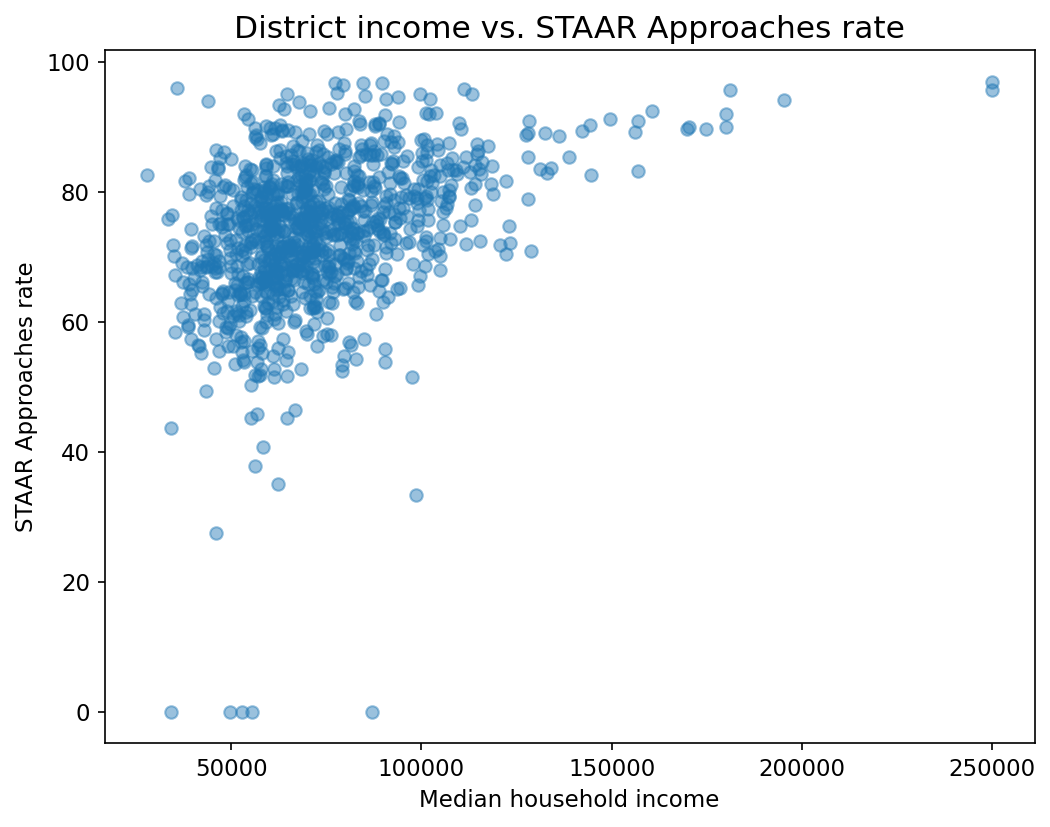

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    analysis["median_household_income"],
    analysis["approaches_pct"],
    alpha=0.45,
)

ax.set_title("District income vs. STAAR Approaches rate")
ax.set_xlabel("Median household income")
ax.set_ylabel("STAAR Approaches rate")

plt.show()

This looks very messy! The vast majority of districts are under 120k. All of the 0 star approaches rate are small districts 

Lets try looking at districts with > 500 tests taken. 

Note that this still includes small districts, 500 total tests is still possible with just a few hundred students

In [25]:
# Regression sample: usable income data and at least 500 STAAR tests.

regression_data = analysis[
    analysis["median_household_income"].notna()
    & (analysis["tests_taken"] >= 500)
].copy()

regression_data["is_sa_area"] = (
    regression_data["tea_district_id"].isin(sa_area_tea_ids)
)

print(f"Districts used in regression: {len(regression_data):,}")

Districts used in regression: 748


Districts in scatterplot: 748


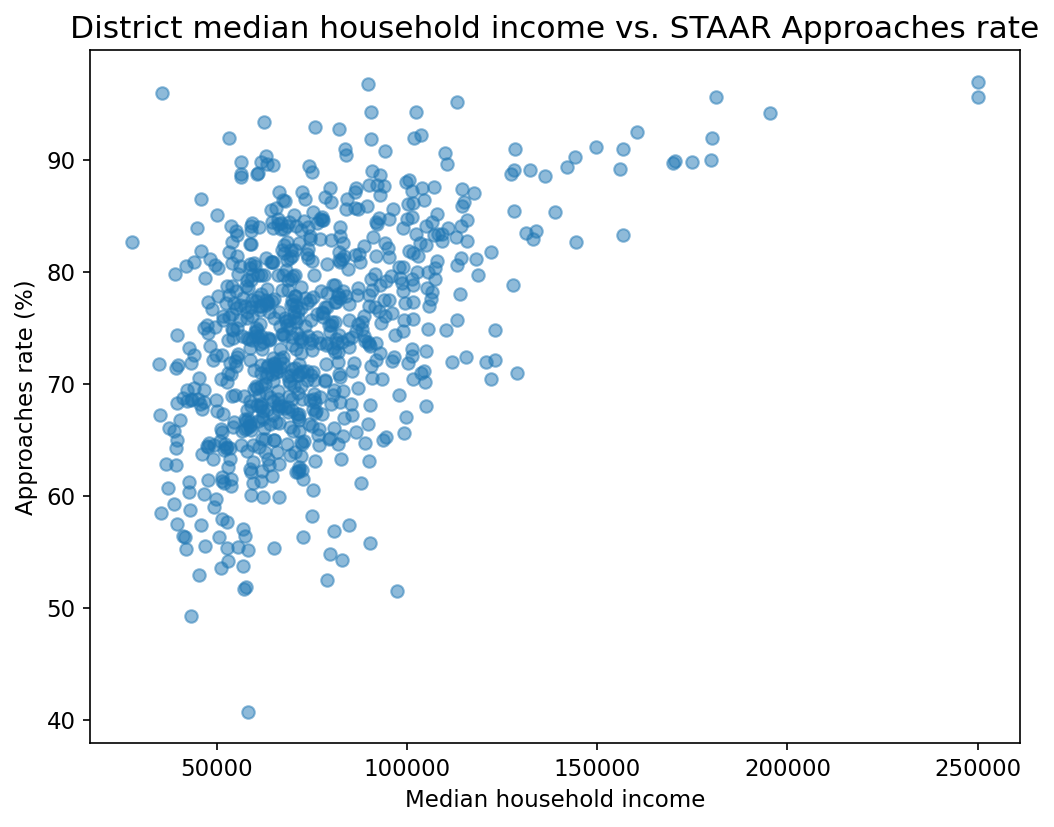

In [26]:
# Scatterplot using districts with at least 500 included STAAR test administrations.

scatter_data = analysis[
    analysis["median_household_income"].notna()
    & (analysis["tests_taken"] >= 500)
].copy()

print(f"Districts in scatterplot: {len(scatter_data):,}")

plt.figure(figsize=(8, 6))

plt.scatter(
    scatter_data["median_household_income"],
    scatter_data["approaches_pct"],
    alpha=0.5,
)

plt.title("District median household income vs. STAAR Approaches rate")
plt.xlabel("Median household income")
plt.ylabel("Approaches rate (%)")

plt.show()

This is a lot better! The trend line would certainly look better if we didn't have like 20 or so (eyeballing) districts >150k, but I do not think it would be good to remove them

In [27]:
# Poorest and richest districts in the regression sample.

regression_data[
    [
        "staar_district",
        "tea_district_id",
        "median_household_income",
        "approaches_pct",
        "tests_taken",
    ]
].sort_values("median_household_income").iloc[[0, -1]]

,staar_district,tea_district_id,median_household_income,approaches_pct,tests_taken
787,ROMA ISD,214903,27843.0,82.689355,7816.0
419,HIGHLAND PARK ISD,057911,250001.0,96.996691,7858.0


## Simple statewide regression

This is a simple one-variable regression:

```text
STAAR Approaches rate ~ median household income
```

This is useful as a descriptive baseline. It is not a causal model.


In [28]:
# Fit a simple linear regression using districts with at least
# 500 included STAAR test administrations.

regression = linregress(
    regression_data["median_household_income"],
    regression_data["approaches_pct"],
)

regression_summary = pd.DataFrame(
    [
        {
            "slope_per_dollar": regression.slope,
            "slope_per_10000_dollars": regression.slope * 10_000,
                        "slope_per_15000_dollars": regression.slope * 15_000,

                        "slope_per_20000_dollars": regression.slope * 20_000,

            "intercept": regression.intercept,
            "r_value": regression.rvalue,
            "r_squared": regression.rvalue ** 2,
            "p_value": regression.pvalue,
            "standard_error": regression.stderr,
            "n_districts": len(regression_data),
        }
    ]
)

regression_summary

# great p value lol (<.001, hightly statistically significant)
# R-squared of 22% makes sense to me
# There are a lot of other factors besides income (class size, demographics, etc.) 

,slope_per_dollar,slope_per_10000_dollars,slope_per_15000_dollars,slope_per_20000_dollars,intercept,r_value,r_squared,p_value,standard_error,n_districts
0,0.000167,1.665776,2.498664,3.331552,62.080479,0.469227,0.220174,3.215434e-42,0.000011,748


In [29]:
analysis[
    analysis["median_household_income"] > 150000
][
    [
        "income_district",
        "median_household_income",
        "income_moe",
        "approaches_pct",
    ]
]
# only 13 districts with 150k+ median household income, and only 2 with 200k+ median household income
# Still waiting on clarifiacation from NGHIS on 2500001

,income_district,median_household_income,income_moe,approaches_pct
10,Aledo ISD,156900.0,10109.0,90.981894
33,Argyle ISD,180095.0,14742.0,91.964486
142,Carroll ISD,250001.0,NaN,95.659558
149,Celina ISD,156852.0,19956.0,83.305469
202,Coppell ISD,160589.0,10919.0,92.470925
264,Dripping Springs ISD,169874.0,15997.0,89.705261
271,Eanes ISD,195329.0,13185.0,94.211344
419,Highland Park ISD (Dallas County),250001.0,NaN,96.996691
510,Lake Travis ISD,156087.0,14563.0,89.206090
550,London ISD,179913.0,30981.0,90.017889


In [30]:
# Add fitted values and residuals for the regression sample.
# This keeps the residual analysis consistent with the model universe:
# districts with usable income data and at least 500 included STAAR tests.

regression_data["predicted_approaches_pct"] = (
    regression.intercept
    + regression.slope * regression_data["median_household_income"]
)

regression_data["residual"] = (
    regression_data["approaches_pct"]
    - regression_data["predicted_approaches_pct"]
)

regression_data[
    [
        "staar_district",
        "median_household_income",
        "approaches_pct",
        "predicted_approaches_pct",
        "residual",
        "tests_taken",
    ]
].head()

,staar_district,median_household_income,approaches_pct,predicted_approaches_pct,residual,tests_taken
1,ABERNATHY ISD,83073.0,82.596934,75.918580,6.678354,1109.0
2,ABILENE ISD,58822.0,66.602656,71.878907,-5.276251,18226.0
3,ACADEMY ISD,95390.0,81.325068,77.970317,3.354751,2581.0
6,ALAMO HEIGHTS ISD,100268.0,86.071542,78.782882,7.288659,6318.0
7,ALBA-GOLDEN ISD,66000.0,79.744346,73.074601,6.669745,1017.0


In [31]:
regression_data[
    regression_data["predicted_approaches_pct"] > 100
][
    [
        "staar_district",
        "median_household_income",
        "approaches_pct",
        "predicted_approaches_pct",
        "tests_taken",
    ]
].sort_values("predicted_approaches_pct", ascending=False)

#Unfortunately this model breaks on the high income districts


,staar_district,median_household_income,approaches_pct,predicted_approaches_pct,tests_taken
142,CARROLL ISD,250001.0,95.659558,103.725046,10598.0
419,HIGHLAND PARK ISD,250001.0,96.996691,103.725046,7858.0


In [32]:
print(
    regression_data["predicted_approaches_pct"].describe()
)

count    748.000000
mean      74.633252
std        4.221422
min       66.718499
25%       71.928172
50%       73.821452
75%       76.503476
max      103.725046
Name: predicted_approaches_pct, dtype: float64


## Scatterplot with regression line and SA-area highlights

The gray dots are all matched districts.

The highlighted points are the San Antonio-area districts.


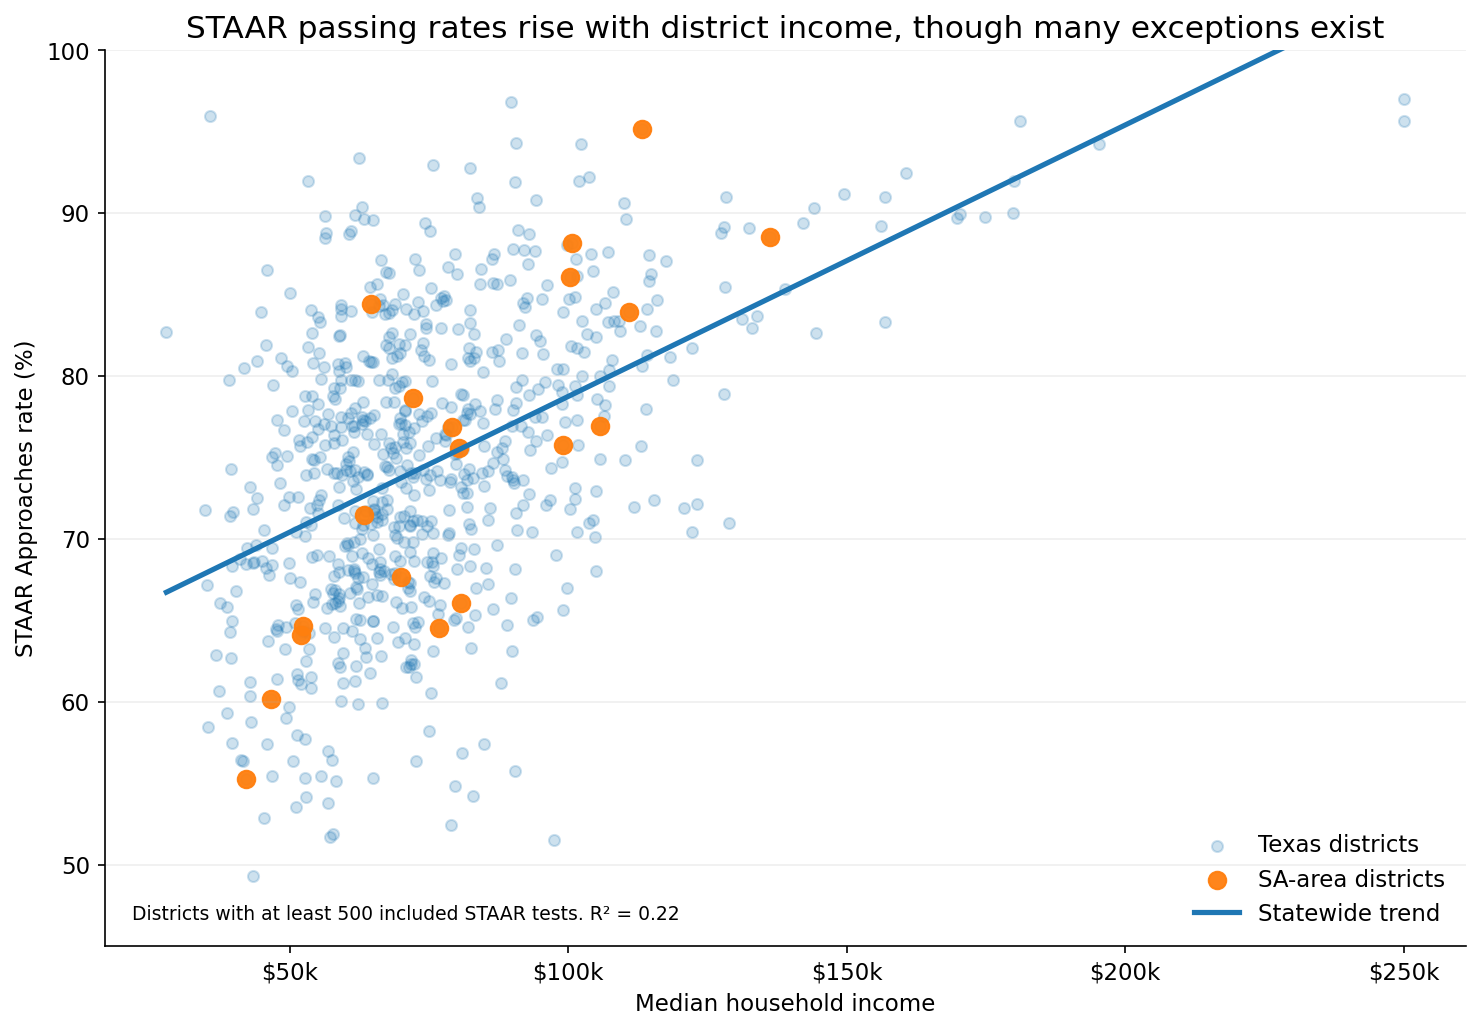

In [34]:
plot_data = regression_data.copy()

x_line = np.linspace(
    plot_data["median_household_income"].min(),
    plot_data["median_household_income"].max(),
    100,
)

y_line = (
    regression.intercept
    + regression.slope * x_line
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    plot_data["median_household_income"],
    plot_data["approaches_pct"],
    s=28,
    alpha=0.22,
    label="Texas districts",
)

ax.scatter(
    plot_data.loc[plot_data["is_sa_area"], "median_household_income"],
    plot_data.loc[plot_data["is_sa_area"], "approaches_pct"],
    s=70,
    alpha=0.95,
    label="SA-area districts",
)

ax.plot(x_line, y_line, linewidth=2.5, label="Statewide trend")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1000:.0f}k"))
ax.set_ylim(45, 100)

ax.set_title("STAAR passing rates rise with district income, though many exceptions exist")
ax.set_xlabel("Median household income")
ax.set_ylabel("STAAR Approaches rate (%)")

ax.text(
    0.02,
    0.03,
    f"Districts with at least 500 included STAAR tests. R² = {regression.rvalue**2:.2f}",
    transform=ax.transAxes,
    fontsize=9,
)

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

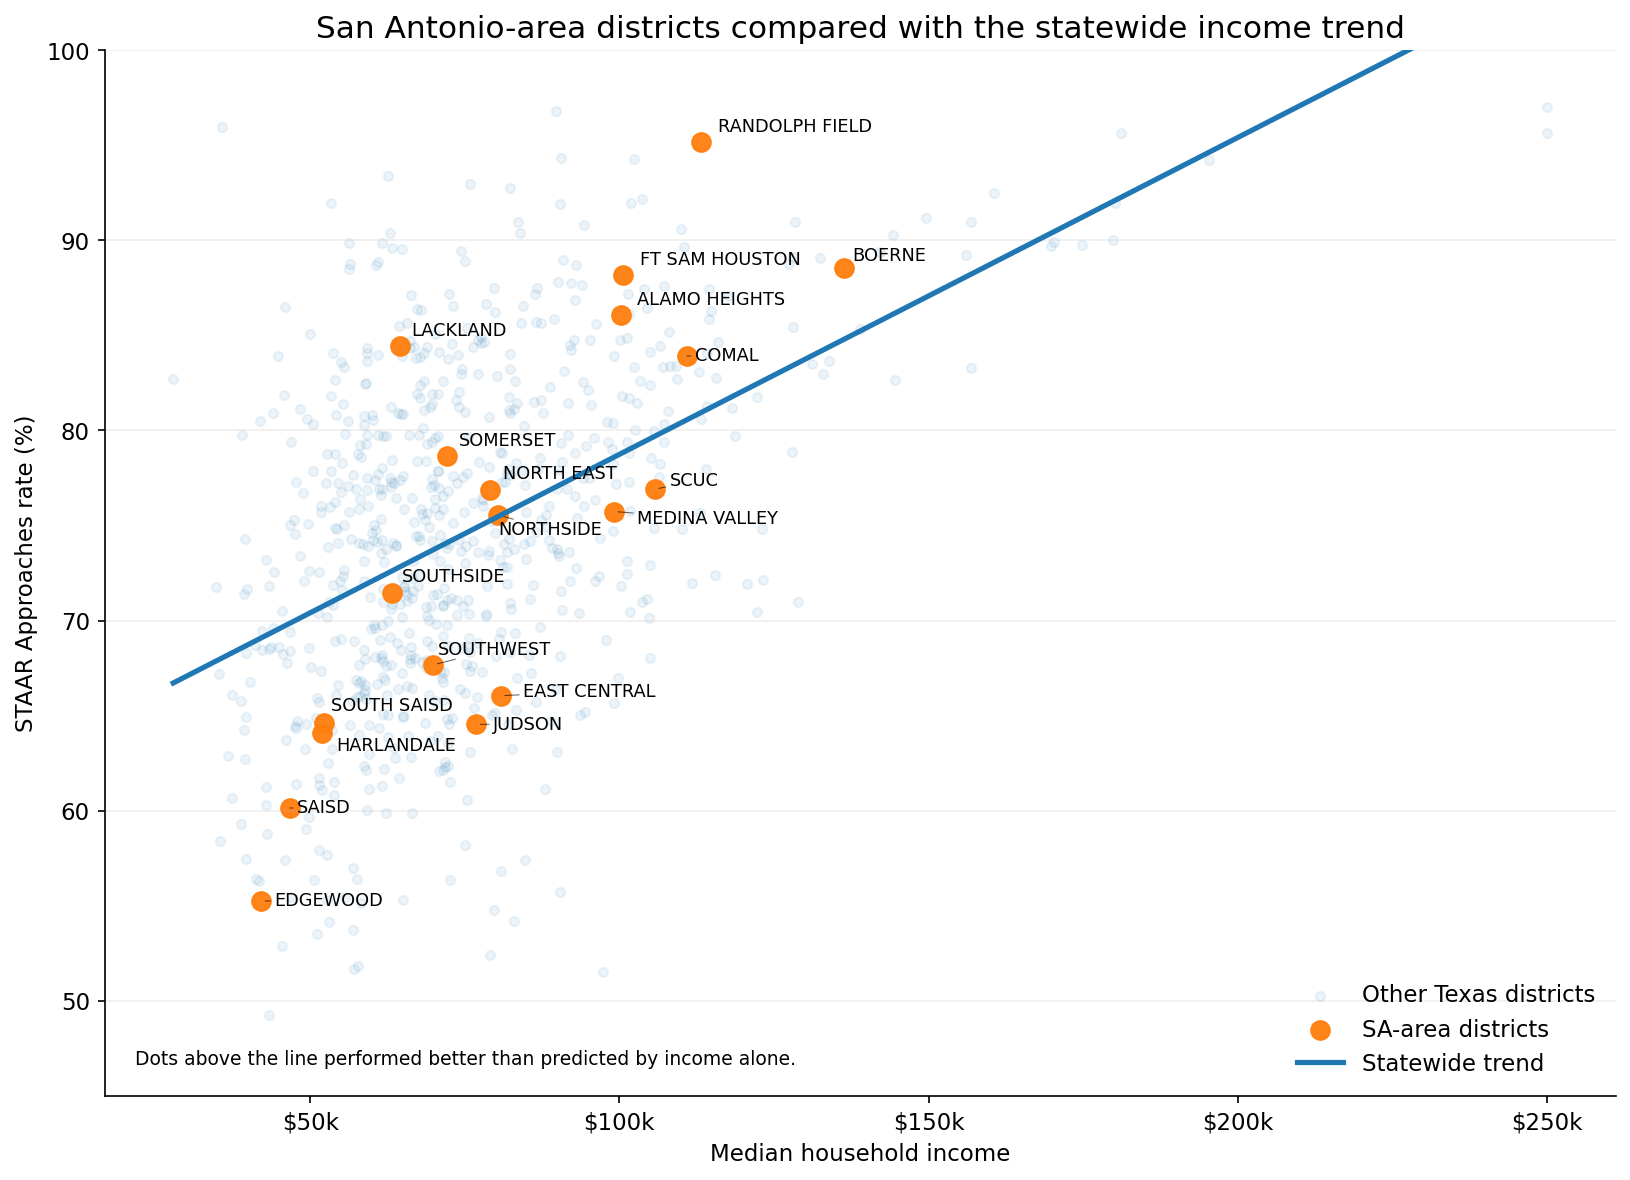

In [ ]:
sa_plot_data = regression_data[regression_data["is_sa_area"]].copy()

fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    regression_data.loc[~regression_data["is_sa_area"], "median_household_income"],
    regression_data.loc[~regression_data["is_sa_area"], "approaches_pct"],
    s=20,
    alpha=0.08,
    label="Other Texas districts",
)

ax.scatter(
    sa_plot_data["median_household_income"],
    sa_plot_data["approaches_pct"],
    s=80,
    alpha=0.95,
    label="SA-area districts",
)

ax.plot(x_line, y_line, linewidth=2.5, label="Statewide trend")

texts = []
for _, row in sa_plot_data.iterrows():
    label = (
        row["staar_district"]
        .replace(" ISD", "")
        .replace("SCHERTZ-CIBOLO-U CITY", "SCUC")
        .replace("SAN ANTONIO", "SAISD")
        .replace("SOUTH SAN ANTONIO", "South San")
    )
    texts.append(
        ax.text(
            row["median_household_income"],
            row["approaches_pct"],
            label,
            fontsize=8.5,
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", lw=0.5, alpha=0.6),
)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1000:.0f}k"))
ax.set_ylim(45, 100)

ax.set_title("San Antonio-area districts compared with the statewide income trend")
ax.set_xlabel("Median household income")
ax.set_ylabel("STAAR Approaches rate (%)")

ax.text(
    0.02,
    0.03,
    "Dots above the line performed better than predicted by income alone.",
    transform=ax.transAxes,
    fontsize=9,
)

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## Statewide over- and under-performers

Residuals compare actual STAAR performance with the performance predicted by the statewide income relationship.

Positive residual:

```text
actual STAAR rate is five or more percentage points higher than predicted
```

Negative residual:

```text
actual STAAR rate is five or more percentage points lower than predicted
```

Do not use the language "underpeformer" or "overperformer" in the actual copy.

In [ ]:
# Districts performing at least 5 percentage points above or below
# the statewide income trend.

overperformers = (
    regression_data[
        regression_data["residual"] >= 5
    ]
    .sort_values("residual", ascending=False)
)

underperformers = (
    regression_data[
        regression_data["residual"] <= -5
    ]
    .sort_values("residual")
)

print(f"Overperformers (≥5 percentage points): {len(overperformers)}")
display(
    overperformers[
        [
            "staar_district",
            "median_household_income",
            "approaches_pct",
            "predicted_approaches_pct",
            "residual",
            "tests_taken",
        ]
    ].reset_index(drop=True)
)

print(f"\nUnderperformers (≤−5 percentage points): {len(underperformers)}")
display(
    underperformers[
        [
            "staar_district",
            "median_household_income",
            "approaches_pct",
            "predicted_approaches_pct",
            "residual",
            "tests_taken",
        ]
    ].reset_index(drop=True)
)

Overperformers (≥5 percentage points): 200


,staar_district,median_household_income,approaches_pct,predicted_approaches_pct,residual,tests_taken
0,MUMFORD ISD,35724.0,95.966620,68.031297,27.935323,719.0
1,SANTA GERTRUDIS ISD,53333.0,91.935484,70.964562,20.970921,806.0
2,SUNDOWN ISD,62500.0,93.396226,72.491579,20.904647,742.0
3,FALLS CITY ISD,89677.0,96.801347,77.018659,19.782688,594.0
4,GEORGE WEST ISD,56342.0,89.830508,71.465795,18.364714,1357.0
...,...,...,...,...,...,...
195,ROBINSON ISD,108023.0,85.161680,80.074692,5.086989,3309.0
196,PEARLAND ISD,114890.0,86.264651,81.218580,5.046071,28241.0
197,ALVORD ISD,86250.0,81.474978,76.447797,5.027181,1139.0
198,YOAKUM ISD,53128.0,75.949367,70.930414,5.018953,1659.0



Underperformers (≤−5 percentage points): 202


,staar_district,median_household_income,approaches_pct,predicted_approaches_pct,residual,tests_taken
0,ROSCOE COLLEGIATE ISD,58304.0,40.708900,71.792620,-31.083720,14191.0
1,MANOR ISD,97415.0,51.513497,78.307636,-26.794140,12818.0
2,FORT STOCKTON ISD,79028.0,52.432207,75.244774,-22.812567,11985.0
3,HALLSVILLE ISD,82924.0,54.212905,75.893760,-21.680855,42263.0
4,ELGIN ISD,90375.0,55.751772,77.134930,-21.383158,8041.0
...,...,...,...,...,...,...
197,PLEASANTON ISD,66925.0,68.035464,73.228685,-5.193221,4286.0
198,SAN FELIPE-DEL RIO CISD,66104.0,67.986561,73.091925,-5.105364,12501.0
199,HENDERSON ISD,69754.0,68.645731,73.699933,-5.054202,4076.0
200,REAGAN COUNTY ISD,57813.0,66.699029,71.710830,-5.011801,1030.0


## San Antonio-area residuals

This uses the same statewide regression line, then looks only at the San Antonio-area districts.

That lets us ask which local districts are above or below the statewide income trend.


In [ ]:
# Classify SA-area districts based on how far they are from the statewide income trend.
# Residuals are measured in percentage points.

sa_area_analysis = regression_data[
    regression_data["is_sa_area"]
].copy()

sa_area_analysis["performance_category"] = pd.cut(
    sa_area_analysis["residual"],
    bins=[-float("inf"), -5, 5, float("inf")],
    labels=[
        "Under expected",
        "About expected",
        "Over expected",
    ],
)

sa_area_analysis = (
    sa_area_analysis
    .sort_values("residual", ascending=False)
    .reset_index(drop=True)
)

display_cols = [
    "staar_district",
    "tea_district_id",
    "median_household_income",
    "income_moe",
    "approaches_pct",
    "predicted_approaches_pct",
    "residual",
    "tests_taken",
    "performance_category",
]

print("SA-area districts over expected:")
display(
    sa_area_analysis[
        sa_area_analysis["performance_category"] == "Over expected"
    ][display_cols]
)

print("SA-area districts about expected:")
display(
    sa_area_analysis[
        sa_area_analysis["performance_category"] == "About expected"
    ][display_cols]
)

print("SA-area districts under expected:")
display(
    sa_area_analysis[
        sa_area_analysis["performance_category"] == "Under expected"
    ][display_cols]
)

SA-area districts over expected:


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
0,RANDOLPH FIELD ISD,015906,113250.0,22031.0,95.151199,80.945393,14.205806,1918.0,Over expected
1,LACKLAND ISD,015913,64539.0,15330.0,84.412266,72.831231,11.581035,1174.0,Over expected
2,FT SAM HOUSTON ISD,015914,100662.0,21360.0,88.161994,78.848514,9.313480,1926.0,Over expected
3,ALAMO HEIGHTS ISD,015901,100268.0,10037.0,86.071542,78.782882,7.288659,6318.0,Over expected


SA-area districts about expected:


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
4,SOMERSET ISD,015909,72176.0,8968.0,78.650190,74.103384,4.546806,5260.0,About expected
5,BOERNE ISD,130901,136279.0,10659.0,88.551570,84.781508,3.770062,15251.0,About expected
6,COMAL ISD,046902,110926.0,3282.0,83.915152,80.558266,3.356885,41250.0,About expected
7,NORTH EAST ISD,015910,79074.0,1581.0,76.886172,75.252437,1.633736,71494.0,About expected
8,NORTHSIDE ISD,015915,80406.0,1191.0,75.549275,75.474318,0.074957,127031.0,About expected
9,SOUTHSIDE ISD,015917,63269.0,6564.0,71.471867,72.619678,-1.147810,7589.0,About expected
10,SCHERTZ-CIBOLO-U CITY ISD,094902,105726.0,3973.0,76.903750,79.692063,-2.788313,20696.0,About expected
11,MEDINA VALLEY ISD,163908,99115.0,6604.0,75.734329,78.590818,-2.856490,14469.0,About expected


SA-area districts under expected:


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
12,SOUTHWEST ISD,015912,69907.0,4627.0,67.671906,73.725420,-6.053513,19531.0,Under expected
13,SOUTH SAN ANTONIO ISD,015908,52309.0,3979.0,64.626796,70.793987,-6.167191,8628.0,Under expected
14,HARLANDALE ISD,015904,51927.0,3821.0,64.109608,70.730354,-6.620746,14196.0,Under expected
15,EAST CENTRAL ISD,015911,80803.0,6282.0,66.049502,75.540449,-9.490947,15555.0,Under expected
16,SAN ANTONIO ISD,015907,46710.0,1609.0,60.148448,69.861319,-9.712872,51466.0,Under expected
17,JUDSON ISD,015916,76852.0,3281.0,64.546170,74.882301,-10.336131,29207.0,Under expected
18,EDGEWOOD ISD,015905,42055.0,1987.0,55.257825,69.085900,-13.828075,8882.0,Under expected


In [ ]:
# Classify Austin/Travis-area districts based on how far they are
# from the statewide income trend.

travis_area_tea_ids = [ # will need to confirm that all of these touch Travis county 
    "227901",  # Austin ISD
    "227904",  # Pflugerville ISD
    "227907",  # Manor ISD
    "246904",  # Georgetown ISD
    "246913",  # Leander ISD
    "246909",  # Round Rock ISD
    "227909",  # Eanes ISD
    "227912",  # Lago Vista ISD
    "227913",  # Lake Travis ISD
    "011902",  # Elgin ISD
]

regression_data["is_travis_area"] = (
    regression_data["tea_district_id"].isin(travis_area_tea_ids)
)

travis_area_analysis = regression_data[
    regression_data["is_travis_area"]
].copy()

travis_area_analysis["performance_category"] = pd.cut(
    travis_area_analysis["residual"],
    bins=[-float("inf"), -5, 5, float("inf")],
    labels=[
        "Under expected",
        "About expected",
        "Over expected",
    ],
)

travis_area_analysis = (
    travis_area_analysis
    .sort_values("residual", ascending=False)
    .reset_index(drop=True)
)

display_cols = [
    "staar_district",
    "tea_district_id",
    "median_household_income",
    "income_moe",
    "approaches_pct",
    "predicted_approaches_pct",
    "residual",
    "tests_taken",
    "performance_category",
]

print("Austin/Travis-area districts over expected:")
display(
    travis_area_analysis[
        travis_area_analysis["performance_category"] == "Over expected"
    ][display_cols]
)

print("Austin/Travis-area districts about expected:")
display(
    travis_area_analysis[
        travis_area_analysis["performance_category"] == "About expected"
    ][display_cols]
)

print("Austin/Travis-area districts under expected:")
display(
    travis_area_analysis[
        travis_area_analysis["performance_category"] == "Under expected"
    ][display_cols]
)

# ok this is kind of major!!

# Within Travis County, only two districts did better than predicted by income alone: Round Rock and Lake Travis. Neither beat the five percentage point threshold

# The majority did worse than predicted by income alone, with Elgin and Manor ISD performing 20+ percentage points worse than predicted by income alone.

Austin/Travis-area districts over expected:


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category


Austin/Travis-area districts about expected:


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
0,ROUND ROCK ISD,246909,108174.0,2738.0,83.384987,80.099845,3.285142,59693.0,About expected
1,LAKE TRAVIS ISD,227913,156087.0,14563.0,89.206090,88.081077,1.125013,14712.0,About expected
2,EANES ISD,227909,195329.0,13185.0,94.211344,94.617916,-0.406572,10296.0,About expected
3,LEANDER ISD,246913,133971.0,3764.0,83.669619,84.397047,-0.727428,55657.0,About expected
4,AUSTIN ISD,227901,92946.0,1834.0,72.749876,77.563201,-4.813325,86873.0,About expected


Austin/Travis-area districts under expected:


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
5,LAGO VISTA ISD,227912,113058.0,14100.0,75.678867,80.913410,-5.234543,2541.0,Under expected
6,PFLUGERVILLE ISD,227904,101238.0,4039.0,73.126159,78.944463,-5.818304,33434.0,Under expected
7,GEORGETOWN ISD,246904,104990.0,4395.0,72.919405,79.569462,-6.650057,19021.0,Under expected
8,ELGIN ISD,011902,90375.0,11216.0,55.751772,77.134930,-21.383158,8041.0,Under expected
9,MANOR ISD,227907,97415.0,7159.0,51.513497,78.307636,-26.794140,12818.0,Under expected


In [ ]:
hill_country_tea_ids = [  # Very arbitrary. Still need to define this more carefully before publication.
    "130901",  # Boerne ISD
    "130902",  # Comfort ISD
    "046902",  # Comal ISD
    "046901",  # New Braunfels ISD
    "105906",  # Hays CISD
    "105905",  # Wimberley ISD
    "105904",  # Dripping Springs ISD
    "105902",  # San Marcos CISD
    "016902",  # Blanco ISD
    "027904",  # Marble Falls ISD
    "163908",  # Medina Valley ISD
    "010902",  # Bandera ISD
    "133901",  # Center Point ISD
    "133903",  # Kerrville ISD
    "086901",  # Fredericksburg ISD
]

# Classify Hill Country districts based on how far they are
# from the statewide income trend.

regression_data["is_hill_country"] = (
    regression_data["tea_district_id"].isin(hill_country_tea_ids)
)

hill_country_analysis = regression_data[
    regression_data["is_hill_country"]
].copy()

hill_country_analysis["performance_category"] = pd.cut(
    hill_country_analysis["residual"],
    bins=[-float("inf"), -5, 5, float("inf")],
    labels=[
        "Under expected",
        "About expected",
        "Over expected",
    ],
)

hill_country_analysis = (
    hill_country_analysis
    .sort_values("residual", ascending=False)
    .reset_index(drop=True)
)

display_cols = [
    "staar_district",
    "tea_district_id",
    "median_household_income",
    "income_moe",
    "approaches_pct",
    "predicted_approaches_pct",
    "residual",
    "tests_taken",
    "performance_category",
]

print("Hill Country districts over expected:")
display(
    hill_country_analysis[
        hill_country_analysis["performance_category"] == "Over expected"
    ][display_cols]
)

print("Hill Country districts about expected:")
display(
    hill_country_analysis[
        hill_country_analysis["performance_category"] == "About expected"
    ][display_cols]
)

print("Hill Country districts under expected:")
display(
    hill_country_analysis[
        hill_country_analysis["performance_category"] == "Under expected"
    ][display_cols]
)

# vast majority perform as expected, with Wimberely ISD beating the odds by eight percentage points 
# comfort isd is interesting, six-figure income districts usually meet or exceed (eyeballing, can look at quintiles later)

Hill Country districts over expected:


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
0,WIMBERLEY ISD,105905,82389.0,14995.0,84.038997,75.804641,8.234356,3590.0,Over expected


Hill Country districts about expected:


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
1,KERRVILLE ISD,133903,65030.0,4507.0,77.604349,72.913021,4.691329,5702.0,About expected
2,BOERNE ISD,130901,136279.0,10659.0,88.551570,84.781508,3.770062,15251.0,About expected
3,COMAL ISD,046902,110926.0,3282.0,83.915152,80.558266,3.356885,41250.0,About expected
4,FREDERICKSBURG ISD,086901,75388.0,7856.0,77.735849,74.638432,3.097418,3975.0,About expected
5,BLANCO ISD,016902,101591.0,14256.0,78.818737,79.003264,-0.184527,1473.0,About expected
6,NEW BRAUNFELS ISD,046901,98942.0,6666.0,78.245947,78.562000,-0.316053,13694.0,About expected
7,DRIPPING SPRINGS ISD,105904,169874.0,15997.0,89.705261,90.377683,-0.672422,11841.0,About expected
8,BANDERA ISD,010902,75021.0,7414.0,73.018033,74.577298,-1.559264,2939.0,About expected
9,MEDINA VALLEY ISD,163908,99115.0,6604.0,75.734329,78.590818,-2.856490,14469.0,About expected
10,CENTER POINT ISD,133901,81892.0,18390.0,72.812500,75.721852,-2.909352,640.0,About expected


Hill Country districts under expected:


,staar_district,tea_district_id,median_household_income,income_moe,approaches_pct,predicted_approaches_pct,residual,tests_taken,performance_category
13,MARBLE FALLS ISD,027904,75649.0,6586.0,69.097816,74.681908,-5.584093,5265.0,Under expected
14,COMFORT ISD,130902,101250.0,18104.0,72.434916,78.946461,-6.511546,1306.0,Under expected



Texas has many tiny districts. This check repeats the regression for districts with at least 10,000 included test administrations.

This is not the main model. I was just curious

In [ ]:
# Large-district sensitivity check.
# This uses districts with usable income data and at least 1,000 included STAAR tests.

large_districts = analysis[
    analysis["median_household_income"].notna()
    & (analysis["tests_taken"] >= 1000)
].copy()

large_regression = linregress(
    large_districts["median_household_income"],
    large_districts["approaches_pct"],
)

large_regression_summary = pd.DataFrame(
    [
        {
            "slope_per_dollar": large_regression.slope,
            "slope_per_10000_dollars": large_regression.slope * 10_000,
            "intercept": large_regression.intercept,
            "r_value": large_regression.rvalue,
            "r_squared": large_regression.rvalue ** 2,
            "p_value": large_regression.pvalue,
            "standard_error": large_regression.stderr,
            "n_districts": len(large_districts),
        }
    ]
)

large_regression_summary

,slope_per_dollar,slope_per_10000_dollars,intercept,r_value,r_squared,p_value,standard_error,n_districts
0,0.000176,1.755004,60.214665,0.541619,0.293351,9.180302e-45,0.000011,570


One more alternative look - what happens if we straight up 'delete' districts >$160k?

In [ ]:
# High-income sensitivity check.
# This repeats the regression after excluding districts with
# median household incomes above $200,000.

trimmed_districts = analysis[
    analysis["median_household_income"].notna()
    & (analysis["tests_taken"] >= 500)
    & (analysis["median_household_income"] <= 200_000)
].copy()

trimmed_regression = linregress(
    trimmed_districts["median_household_income"],
    trimmed_districts["approaches_pct"],
)

trimmed_regression_summary = pd.DataFrame(
    [
        {
            "slope_per_dollar": trimmed_regression.slope,
            "slope_per_20000_dollars": trimmed_regression.slope * 20_000,
            "intercept": trimmed_regression.intercept,
            "r_value": trimmed_regression.rvalue,
            "r_squared": trimmed_regression.rvalue ** 2,
            "p_value": trimmed_regression.pvalue,
            "standard_error": trimmed_regression.stderr,
            "n_districts": len(trimmed_districts),
        }
    ]
)

print(
    f"Excluded {(regression_data['median_household_income'] > 200_000).sum()} "
    "districts with median household incomes above $200,000."
)

trimmed_regression_summary

#basically the same thing

Excluded 2 districts with median household incomes above $200,000.


,slope_per_dollar,slope_per_20000_dollars,intercept,r_value,r_squared,p_value,standard_error,n_districts
0,0.000173,3.455333,61.636819,0.458173,0.209923,5.443844e-40,0.000012,746


## Export analysis file

This file includes the merged income and STAAR data, plus predicted values and residuals from the statewide regression.


In [ ]:
analysis.to_csv(
    OUTPUT_FILE,
    index=False,
)
# This includes all matched districts, not just those used in the regression.

print(f"Saved {len(analysis):,} districts to:")
print(OUTPUT_FILE)

Saved 1,016 districts to:
../data/processed/district_income_staar_analysis.csv


In [ ]:
analysis.head()

,income_district,district_code,year,state,median_household_income,income_moe,staar_district,tea_district_id,administration,tests_taken,approaches_count,approaches_pct,is_sa_area
0,Abbott ISD,7380,2020-2024,Texas,88750.0,26095.0,ABBOTT ISD,109901,Spring 2026,351.0,318.0,90.598291,False
1,Abernathy ISD,7410,2020-2024,Texas,83073.0,12492.0,ABERNATHY ISD,095901,Spring 2026,1109.0,916.0,82.596934,False
2,Abilene ISD,7440,2020-2024,Texas,58822.0,1489.0,ABILENE ISD,221901,Spring 2026,18226.0,12139.0,66.602656,False
3,Academy ISD,7470,2020-2024,Texas,95390.0,4391.0,ACADEMY ISD,014901,Spring 2026,2581.0,2099.0,81.325068,False
4,Adrian ISD,7500,2020-2024,Texas,73125.0,24647.0,ADRIAN ISD,180903,Spring 2026,188.0,135.0,71.808511,False
